<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/golf/03_angle_and_distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf putting 3 — Angle and distance

Add a second physical failure mode: the ball must be hit not only in the right direction but also approximately the right distance. This notebook uses the Broadie data.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260923
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

DATA_BASE = "https://raw.githubusercontent.com/opherdonchin/BayesShortCourse/main/golf/data"
golf = pd.read_csv(f"{DATA_BASE}/broadie_2018_putting.csv")
golf["rate"] = golf["made"] / golf["attempts"]

BALL_RADIUS_FT = (1.68 / 2) / 12
CUP_RADIUS_FT = (4.25 / 2) / 12

golf

PyMC: 6.3.2
arviz-plots: 1.3.1
arviz-stats: 1.3.2


,distance_ft,attempts,made,rate
0,0.28,45198,45183,0.999668
1,0.97,183020,182899,0.999339
2,1.93,169503,168594,0.994637
3,2.92,113094,108953,0.963384
4,3.93,73855,64740,0.876582
5,4.94,53659,41106,0.766060
6,5.94,42991,28205,0.656068
7,6.95,37050,21334,0.575816
8,7.95,33275,16615,0.499324
9,8.95,30836,13503,0.437897


In [3]:
def plot_rate(draws, data, title, *, median_label="median", show_observed=True, ylim=(-0.05, 1.05), show_bounds=False):
    """Plot a probability/rate relationship against continuous putting distance."""
    x = data["distance_ft"].to_numpy()
    curve_dim = next(dim for dim in draws.dims if dim not in ("chain", "draw"))
    order = np.argsort(x)
    draws = draws.isel({curve_dim: order})
    x = x[order]

    median = draws.median(dim=("chain", "draw"))
    interval = draws.azstats.hdi(prob=0.90)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.fill_between(
        x,
        interval.sel(ci_bound="lower"),
        interval.sel(ci_bound="upper"),
        alpha=0.22,
        label="90% HDI",
    )
    ax.plot(x, median, label=median_label)
    if show_observed:
        ax.scatter(x, data["rate"].to_numpy()[order], s=30, color="black", label="observed")
    if show_bounds:
        ax.axhline(0, color="0.6", linewidth=0.8, linestyle="--")
        ax.axhline(1, color="0.6", linewidth=0.8, linestyle="--")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Proportion made",
        title=title,
    )
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=8, frameon=False)
    return ax

def plot_residuals(idata, data, var_name="p_base", title="Residuals"):
    """Plot observed minus posterior-median mechanistic probability."""
    fitted = idata["posterior"][var_name].median(dim=("chain", "draw")).to_numpy()
    x = data["distance_ft"].to_numpy()
    residual = data["rate"].to_numpy() - fitted
    order = np.argsort(x)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.plot(x[order], residual[order], marker="o")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Observed − fitted probability",
        title=title,
    )
    return ax

## Model

We retain the angular component and add a distance-control component. Following Broadie's assumptions, golfers aim one foot past the hole and a putt is viable if it finishes between the hole and three feet beyond it.

The success probability is

$$
p(x)=p_{angle}(x)\,p_{distance}(x).
$$

The two unknown scales are angular error and proportional distance error.

In [4]:
coords = {"obs_id": golf["distance_ft"].to_numpy()}

with pm.Model(coords=coords) as model:
    distance = pm.Data("distance", golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts", golf["attempts"].to_numpy(), dims="obs_id")
    sigma_angle_deg = pm.LogNormal("sigma_angle_deg", mu=np.log(2), sigma=0.7)
    sigma_distance = pm.LogNormal("sigma_distance", mu=np.log(0.10), sigma=0.7)
    distance_tolerance = 3.0
    overshot = 1.0

    sigma_angle_rad = sigma_angle_deg * np.pi / 180
    threshold_angle = pm.math.arcsin((CUP_RADIUS_FT - BALL_RADIUS_FT) / distance)
    p_angle = pm.Deterministic(
        "p_angle",
        2 * pm.math.invprobit(threshold_angle / sigma_angle_rad) - 1,
        dims="obs_id",
    )
    p_distance = pm.Deterministic(
        "p_distance",
        pm.math.invprobit(
            (distance_tolerance - overshot) / ((distance + overshot) * sigma_distance)
        )
        - pm.math.invprobit(
            -overshot / ((distance + overshot) * sigma_distance)
        ),
        dims="obs_id",
    )
    p_base = pm.Deterministic("p_base", p_angle * p_distance, dims="obs_id")
    made = pm.Binomial(
        "made",
        n=attempts,
        p=p_base,
        observed=golf["made"].to_numpy(),
        dims="obs_id",
    )

## Prior predictive check

Before fitting, ask what success rates the prior says are plausible across putting distance. The observed rates are shown only as a reference; they do not condition the prior.

In [5]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["made"],
        random_seed=RANDOM_SEED,
    )

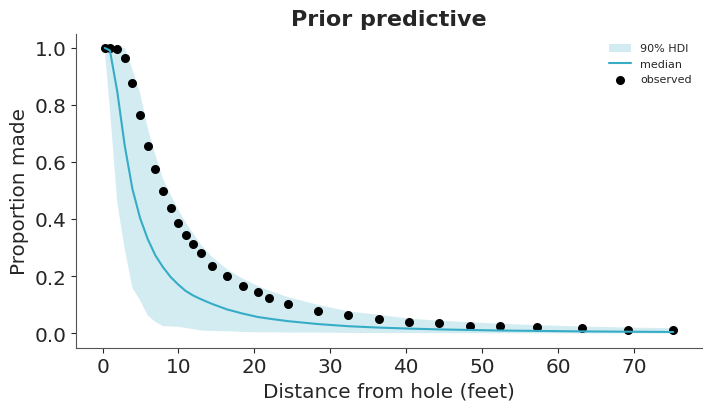

In [6]:
plot_rate(
    prior["prior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Prior predictive",
);

## Fit and diagnose

Do not interpret the scientific fit until the sampler diagnostics are acceptable.

In [7]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata,
    var_names=['sigma_angle_deg', 'sigma_distance'],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Output()

ERROR:pymc.stats.convergence:There were 680 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Divergences: 680


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle_deg,1.75,0.99,0.76,2.76,5.24,11.41,2.43,0.49,0.01
sigma_distance,0.08,0.06,0.01,0.14,5.57,16.56,1.94,0.03,0.00


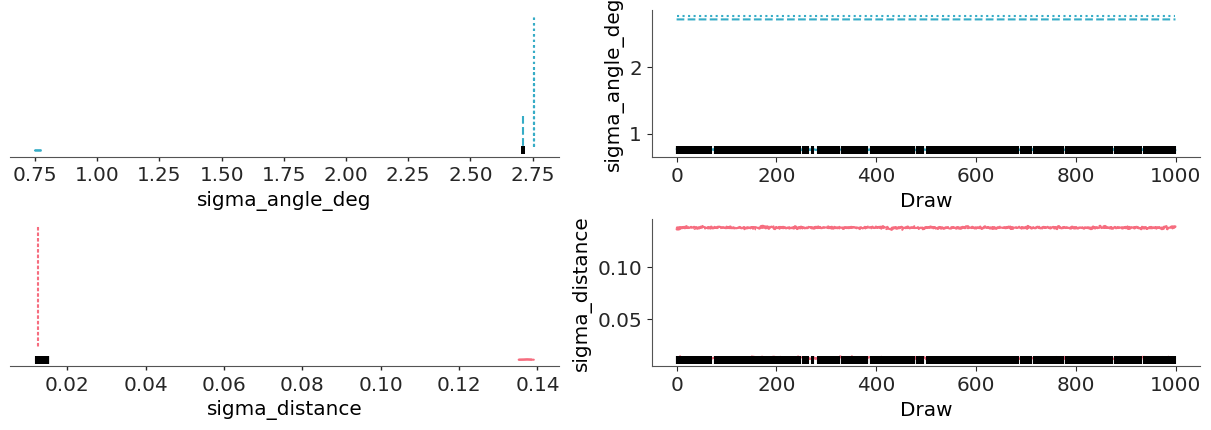

In [8]:
azp.plot_trace_dist(idata, var_names=['sigma_angle_deg', 'sigma_distance']);

## Posterior fit

This plot shows posterior uncertainty in the continuous mechanistic success-probability relationship $p_{base}(x)$. It does not include the additional variation in newly observed successes.

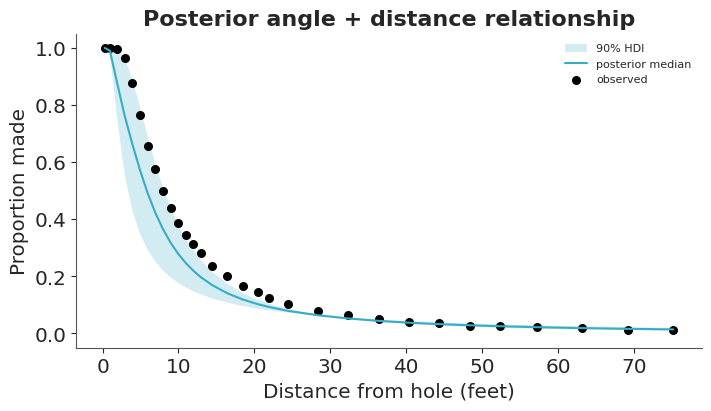

In [9]:
plot_rate(
    idata["posterior"]["p_base"],
    golf,
    "Posterior angle + distance relationship",
    median_label="posterior median",
);

## Posterior predictive check

Now generate new outcomes at the same putting distances from the fitted model. This uses the same graphical grammar as the prior predictive check; the difference is that these predictions are conditioned on the observed data.

In [10]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["made"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Output()

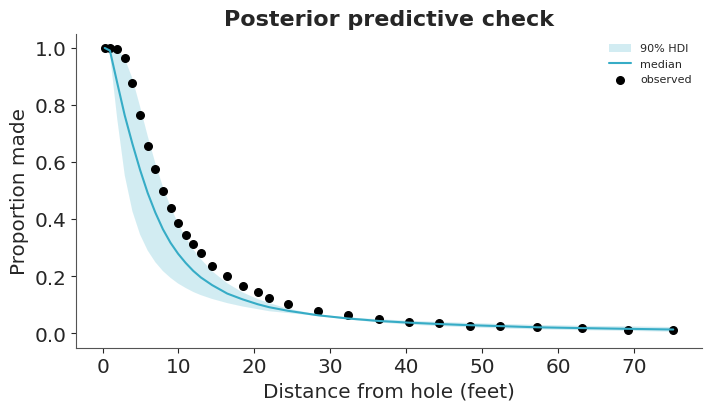

In [11]:
plot_rate(
    idata["posterior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Posterior predictive check",
);

## Model criticism

These residuals compare the observed rates with the posterior-median mechanistic relationship $p_{base}(x)$. They are a check for systematic structure in the mechanism, not a posterior predictive interval.

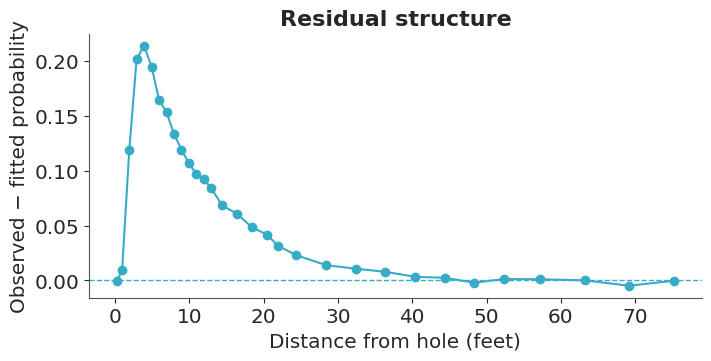

In [12]:
plot_residuals(idata, golf, var_name="p_base", title="Residual structure");

## Decision: reject the observation model

The physical curve is much more plausible, but the residuals show systematic misfit through the middle distances. The Broadie bins contain tens or hundreds of thousands of putts, so a literal Binomial likelihood gives the highest-count bins overwhelming leverage. The likely problem is no longer the basic geometry alone; it is the assumption that binomial sampling variation is the **only** source of discrepancy between the simple mechanism and the aggregated data. **Next notebook:** add model discrepancy.